### Analyze the vae model performance on test set

In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
from collections import defaultdict

import sys
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from peint.data.datamodule import PLMRDataModule
from peint.data.datasets.lept import EncodedLEPTDataset

from peint.models.nets.lept import ProteinVAE
from peint.models.modules.lept_module import ProteinVAEModule

from evo.dataset import ComplexCherriesDataset
from evo.tokenization import Vocab

In [23]:
# load the checkpoint into ProteinVAEModule
ckpt_path = Path("logs/train/runs/2025-10-27_05-06-24/checkpoints/last.ckpt")
module = ProteinVAEModule.load_from_checkpoint(ckpt_path)
module = module.train().cuda()

/accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'net' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['net'])`.


In [24]:
net: ProteinVAE = module.net
vocab: Vocab = getattr(module.net, "vocab")
device = module.device
print(device)
print(vocab)

cuda:0
Vocab({'<cls>': 0, '<pad>': 1, '<eos>': 2, '<unk>': 3, 'L': 4, 'A': 5, 'G': 6, 'V': 7, 'S': 8, 'E': 9, 'R': 10, 'T': 11, 'I': 12, 'D': 13, 'P': 14, 'K': 15, 'Q': 16, 'N': 17, 'F': 18, 'Y': 19, 'M': 20, 'H': 21, 'W': 22, 'C': 23, 'X': 24, 'B': 25, 'U': 26, 'Z': 27, 'O': 28, '.': 29, '-': 30, '<null_1>': 31, '<mask>': 32})


In [25]:
# load the test dataset into an EncodedLEPTDataset and then dataloader
_dataset = ComplexCherriesDataset(
    data_file=Path("data/wyatt/subs/edges_joint/aa/d4.txt"),
    min_t=0.0,
)
dataset = EncodedLEPTDataset(
    dataset=_dataset,
    vocab=vocab,
    swap_prob=0.,
)
dataloader = PLMRDataModule(
    dataset=dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
)._dataloader_template(dataset=dataset, training=False)

In [26]:
# for each transition in test dataset, calculate the reconstruction loss and KL divergence
n_batches = 5
n_interp_points = 10
recon_ppls, kl_divs = [], []
branch_lengths, euc_dists, hamming_dists = [], [], []
interpolations = []

for i, batch in tqdm(enumerate(dataloader), total=n_batches):
    if i >= n_batches:
        break

    batch = [b.to(device) for b in batch]
    x, y, t, x_sizes, y_sizes = batch
    
    with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        x_outputs = net(x=x, x_sizes=x_sizes)
        y_outputs = net(x=y, x_sizes=y_sizes)

    x_logits = x_outputs["logits"].float().detach()      # (batch_size, seq_len-1, vocab_size)
    x_mu = x_outputs["mu"].float().detach()              # (batch_size, latent_dim)
    x_logvar = x_outputs["logvar"].float().detach()      # (batch_size, latent_dim)
    
    y_logits = y_outputs["logits"].float().detach()      # (batch_size, seq_len-1, vocab_size)
    y_mu = y_outputs["mu"].float().detach()              # (batch_size, latent_dim)
    y_logvar = y_outputs["logvar"].float().detach()      # (batch_size, latent_dim)

    # calculate the euclidean distance between x_mu and y_mu
    euc_dist = torch.norm(x_mu - y_mu, dim=1)            # (batch_size,)
    euc_dists.extend(euc_dist.cpu().numpy().tolist())
    branch_lengths.extend(t[:, 0].cpu().numpy().tolist())

    # decode the endpoint sequences (x, y)
    x_seq = vocab.decode(x.cpu().numpy())   # (bs,)
    y_seq = vocab.decode(y.cpu().numpy())   # (bs,)
    
    # linearly interpolate in latent space between x_mu and y_mu
    interp_points = np.linspace(0, 1, n_interp_points)
    batched_seqs = [x_seq]

    for alpha in interp_points:
        z_interp = (1 - alpha) * x_mu + alpha * y_mu    # (batch_size, latent_dim)
        with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            interp_seqs = net.decode(z=z_interp, max_len=x.size(1))

        interp_seqs = interp_seqs.cpu().numpy()     # (batch_size, seq_len)
        interp_seqs = vocab.decode(interp_seqs)     # (batch_size,) list of strings
        batched_seqs.append(interp_seqs)
    
    # finally add the y sequence and pivot the lists, so we have 1 list of sequences per batch item    
    batched_seqs.append(y_seq)
    batched_seqs = list(zip(*batched_seqs))   # (batch_size, n_interp_points + 2)
    interpolations.extend(batched_seqs)

    # calculate the hamming distance between x and y
    n_diff = (x != y).float().sum(dim=1)                  # (batch_size,)
    hamming_dists.extend(n_diff.cpu().numpy().tolist())

    # concatenate the x and y outputs
    logits = torch.cat([x_logits, y_logits], dim=0)      # (2*batch_size, seq_len-1, vocab_size)
    mu = torch.cat([x_mu, y_mu], dim=0)                  # (2*batch_size, latent_dim)
    logvar = torch.cat([x_logvar, y_logvar], dim=0)      # (2*batch_size, latent_dim)

    x_target = x[:, 1:]
    y_target = y[:, 1:]
    target = torch.cat([x_target, y_target], dim=0)      # (2*batch_size, seq_len-1)

    # calculate the reconstruction ppl per sequence
    nll = F.cross_entropy(
        logits.transpose(1, 2),
        target,
        ignore_index=vocab.pad_idx,
        reduction="none",
    )
    target_mask = (target != vocab.pad_idx).float()
    seq_nll = (nll * target_mask).sum(dim=1) / target_mask.sum(dim=1)
    seq_ppl = torch.exp(seq_nll)    # (batch_size,)
    
    # calculate the KL divergence per batch item
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)  # (batch_size,)
    
    # add to lists
    recon_ppls.extend(seq_ppl.cpu().numpy().tolist())
    kl_divs.extend(kl_div.cpu().numpy().tolist())

  0%|                                                                                            | 0/5 [00:00<?, ?it/s]/accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/torch/nn/functional.py:6041: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  warnings.warn(
100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:51<00:00, 10.21s/it]


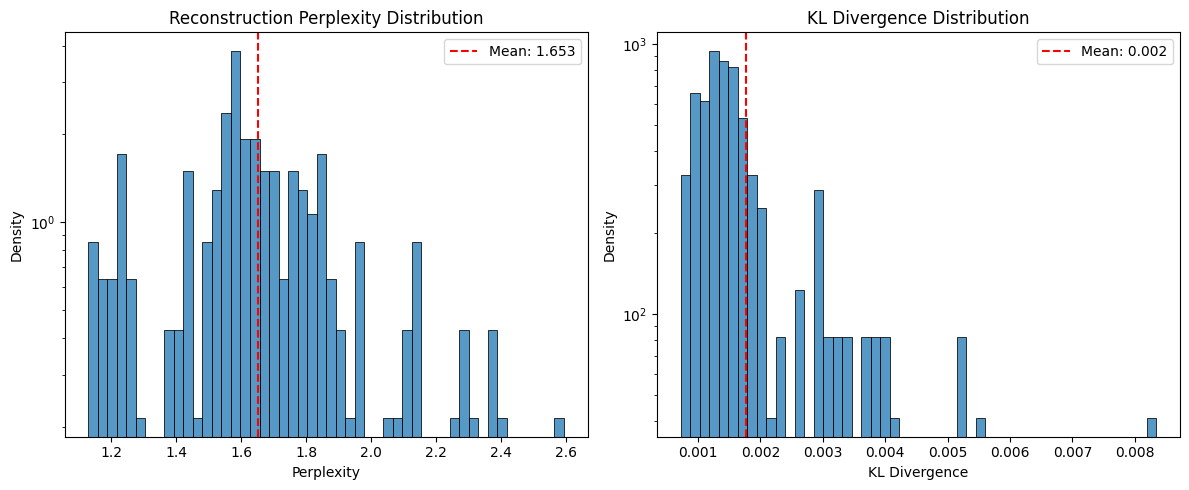

In [27]:
# histogram of the reconstruction ppls and KL divergences
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(recon_ppls, bins=50, kde=False, ax=axes[0], stat="density")
axes[0].set_title("Reconstruction Perplexity Distribution")
axes[0].set_xlabel("Perplexity")
sns.histplot(kl_divs, bins=50, kde=False, ax=axes[1], stat="density")
axes[1].set_title("KL Divergence Distribution")
axes[1].set_xlabel("KL Divergence")

recon_mean = np.mean(recon_ppls)
kl_mean = np.mean(kl_divs)

axes[0].set_yscale("log")
axes[1].set_yscale("log")

# add vertical line for mean
axes[0].axvline(recon_mean, color="red", linestyle="--", label=f"Mean: {recon_mean:.3f}")
axes[0].legend()
axes[1].axvline(kl_mean, color="red", linestyle="--", label=f"Mean: {kl_mean:.3f}")
axes[1].legend()

plt.tight_layout()
plt.show()

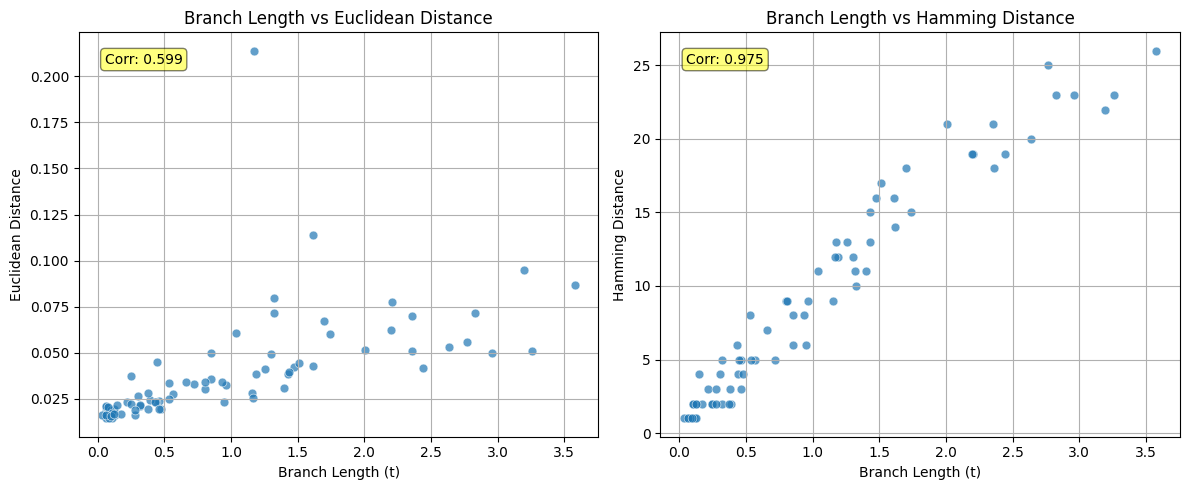

In [28]:
# 1x2 scatter: branch length vs euclidean distance, and branch length vs hamming distance
bl = np.array(branch_lengths)
ed = np.array(euc_dists)
hd = np.array(hamming_dists)

# trim to common length to be safe
minlen = min(len(bl), len(ed), len(hd))
bl, ed, hd = bl[:minlen], ed[:minlen], hd[:minlen]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x=bl, y=ed, ax=axes[0], s=40, alpha=0.7)
corr_ed = np.corrcoef(bl, ed)[0, 1]
axes[0].set_title("Branch Length vs Euclidean Distance")
axes[0].set_xlabel("Branch Length (t)")
axes[0].set_ylabel("Euclidean Distance")
axes[0].annotate(f"Corr: {corr_ed:.3f}", xy=(0.05, 0.95), xycoords="axes fraction",
                 fontsize=10, ha="left", va="top",
                 bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5))
axes[0].grid(True)

sns.scatterplot(x=bl, y=hd, ax=axes[1], s=40, alpha=0.7)
corr_hd = np.corrcoef(bl, hd)[0, 1]
axes[1].set_title("Branch Length vs Hamming Distance")
axes[1].set_xlabel("Branch Length (t)")
axes[1].set_ylabel("Hamming Distance")
axes[1].annotate(f"Corr: {corr_hd:.3f}", xy=(0.05, 0.95), xycoords="axes fraction",
                 fontsize=10, ha="left", va="top",
                 bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5))
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [29]:
interpolations[3]

('EVQLVESGGGLVQPGGSLKLSCAASGFIFSDYDMHWVRQASGKGLEWVGRIRDNTGIYATAYTASVKGRFTISRDDSKSMAYLQMISLKTEDTAVYYCIRRVSDASNSFDYWGRGTLVTVSS.DIVMTQSPLSLPVTPGEPASISCRSSQSLLHSNGYNFLDWYLQKPGKSPQLLIYLGSNRASGVPDRFSGSGSGTDFTLKISRVEAEDVGVYYCMQVLQTPVIFGQGTRLEIK',
 'QVQLVQSGAEVKKPGASVKVSCKASGYTFTSYAMHWVRQAPGQRLEWMGWINAGNGNTKYSQKFQGRVTITRDTSASTAYMELSSLRSEDTAVYYCARDRGYSSSSHYWFDYWGQGTLVTVSS.DIVMTQSPDSLAVSLGERATINCKSSQSVLYSSNNKNYLAWYQQKPGQPPKLLIYWASTRESGVPDRFSGSGSGTDFTLTISSLQAEDVAVYYCQQYYSTPLTFGGGTKVEIK',
 'EVQLVESGGGLVQPGGSLRLSCAASGFTFSSYWMSWVRQAPGKGLEWVANIKQDGSEKYYVDSVKGRFTISRDNAKNSLYLQMNSLRAEDTAVYYCARDGGYYDFWSGYYFDYWGQGTLVTVSS.QSVLTQPPSASGTPGQRVTISCSGSSSNIGSNYVYWYQQLPGTAPKLLIYRNNQRPSGVPDRFSGSKSGTSASLAISGLRSEDEADYYCAAWDDSLSGWVFGGGTKLTVL',
 'QVQLVQSGAEVKKPGASVKVSCKASGYTFTSYAMHWVRQAPGQRLEWMGWINAGNGNTKYSQKFQGRVTITRDTSASTAYMELSSLRSEDTAVYYCARGGSSSWYEGYYYYAMDVWGQGTTVTVSS.DIVMTQSPDSLAVSLGERATINCKSSQSVLYSSNNKNYLAWYQQKPGQPPKLLIYWASTRESGVPDRFSGSGSGTDFTLTISSLQAEDVAVYYCQQYYSTPPTFGQGTKLE',
 'QVQLVQSGAEVKKPGASVKVSCKASGYTFTSYA

In [30]:
def calculate_hamming_dist(seq1: str, seq2: str) -> int:
    """Calculate the Hamming distance between two sequences"""
    max_len = max(len(seq1), len(seq2))
    seq1 = seq1.ljust(max_len, "-")
    seq2 = seq2.ljust(max_len, "-")
    return sum(c1 != c2 for c1, c2 in zip(seq1, seq2))

In [31]:
data = defaultdict(list)

for interp in interpolations:
    heavy_chains, light_chains = [], []
    for i, seq in enumerate(interp):
        hv, lv = seq.split(".")
        heavy_chains.append(hv)
        light_chains.append(lv)

    hv_src, hv_tgt = heavy_chains[0], heavy_chains[-1]
    lv_src, lv_tgt = light_chains[0], light_chains[-1]
    
    # calculate hamming distance between each interpolated sequence and the source and target, pad to maximum length
    hv_dists_to_src = [calculate_hamming_dist(hv, hv_src) for hv in heavy_chains]   # (n_points,)
    hv_dists_to_tgt = [calculate_hamming_dist(hv, hv_tgt) for hv in heavy_chains]
    lv_dists_to_src = [calculate_hamming_dist(lv, lv_src) for lv in light_chains]
    lv_dists_to_tgt = [calculate_hamming_dist(lv, lv_tgt) for lv in light_chains]
    
    # calculate length of each sequence
    hv_lengths = [len(hv) for hv in heavy_chains]
    lv_lengths = [len(lv) for lv in light_chains]
    
    data["hv_dists_to_src"].append(hv_dists_to_src)
    data["hv_dists_to_tgt"].append(hv_dists_to_tgt)
    data["lv_dists_to_src"].append(lv_dists_to_src)
    data["lv_dists_to_tgt"].append(lv_dists_to_tgt)
    
    data["hv_lengths"].append(hv_lengths)
    data["lv_lengths"].append(lv_lengths)

In [32]:
for k, v in data.items():
    data[k] = np.array(v)

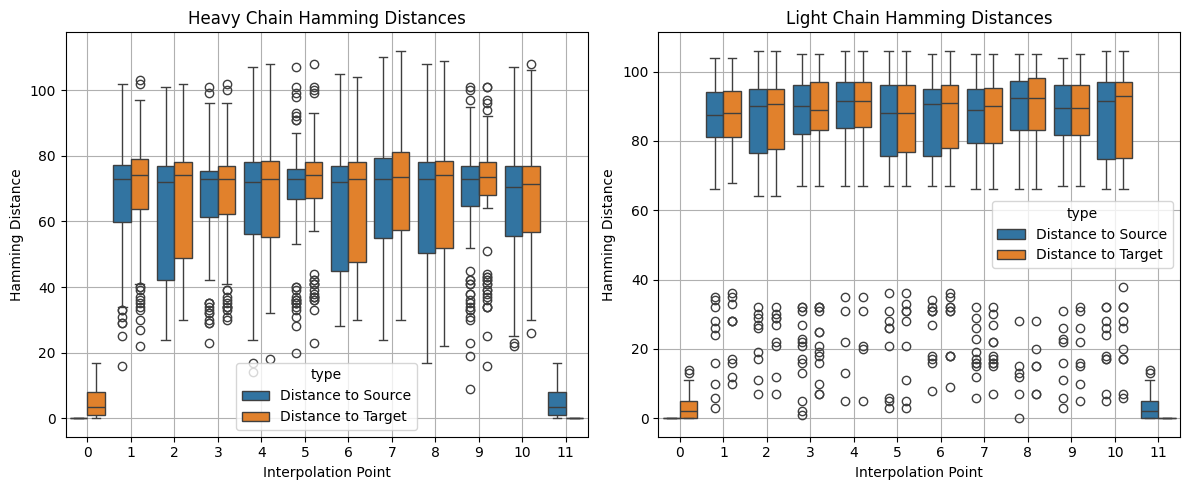

In [33]:
# boxplot hamming distances at each interpolation point
# plot distance to source and target on same plot
# make two plots: one for heavy chain, one for light chain

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

n_interp_points = len(data["hv_dists_to_src"][0])

# Prepare data for heavy chain
hv_data_melted = []
for i in range(n_interp_points):
    for j in range(len(data["hv_dists_to_src"])):
        hv_data_melted.append({'position': i, 'distance': data["hv_dists_to_src"][j][i], 'type': 'Distance to Source'})
        hv_data_melted.append({'position': i, 'distance': data["hv_dists_to_tgt"][j][i], 'type': 'Distance to Target'})

hv_df = pd.DataFrame(hv_data_melted)

# Prepare data for light chain
lv_data_melted = []
for i in range(n_interp_points):
    for j in range(len(data["lv_dists_to_src"])):
        lv_data_melted.append({'position': i, 'distance': data["lv_dists_to_src"][j][i], 'type': 'Distance to Source'})
        lv_data_melted.append({'position': i, 'distance': data["lv_dists_to_tgt"][j][i], 'type': 'Distance to Target'})

lv_df = pd.DataFrame(lv_data_melted)

# Create side-by-side boxplots
sns.boxplot(data=hv_df, x='position', y='distance', hue='type', ax=axes[0])
axes[0].set_title("Heavy Chain Hamming Distances")
axes[0].set_xlabel("Interpolation Point")
axes[0].set_ylabel("Hamming Distance")
axes[0].grid(True)

sns.boxplot(data=lv_df, x='position', y='distance', hue='type', ax=axes[1])
axes[1].set_title("Light Chain Hamming Distances")
axes[1].set_xlabel("Interpolation Point")
axes[1].set_ylabel("Hamming Distance")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# save heavy chain sequences to fasta file

heavy_chains, light_chains = [], []
for i, seq in enumerate(interpolations[0]):
    hv, lv = seq.split(".")
    heavy_chains.append(hv)
    light_chains.append(lv)

outdir = "/accounts/projects/yss/stephen.lu/peint/notebooks/igfold_out"
os.makedirs(outdir, exist_ok=True)

with open(os.path.join(outdir, "heavy.fasta"), "w") as f:
    for i, hv in enumerate(heavy_chains):
        f.write(f">interp_{i}\n")
        f.write(f"{hv}\n")

In [ ]:
# call colabfold_batch on the saved fasta file to predict structures
!colabfold_batch notebooks/igfold_out/heavy.fasta notebooks/igfold_out/heavy_pdb

In [ ]:
# load the pdb files for each predicted structure